In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

c:\Users\sdsha\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data=pd.read_csv('../../Apartment_Price_Predictor/data/processed/hyderabad_cleaned.csv')

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2276 entries, 0 to 2275
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                2276 non-null   float64
 1   area                 2276 non-null   int64  
 2   location             2276 non-null   str    
 3   no_of_bedrooms       2276 non-null   float64
 4   resale               2276 non-null   int64  
 5   maintenancestaff     2276 non-null   float64
 6   gymnasium            2276 non-null   float64
 7   swimmingpool         2276 non-null   float64
 8   landscapedgardens    2276 non-null   float64
 9   joggingtrack         2276 non-null   float64
 10  rainwaterharvesting  2276 non-null   float64
 11  indoorgames          2276 non-null   float64
 12  shoppingmall         2276 non-null   float64
 13  intercom             2276 non-null   float64
 14  sportsfacility       2276 non-null   float64
 15  atm                  2276 non-null   float64
 16 

In [5]:
X=data.drop(columns=['price','log_price'])
y=data['log_price']

In [6]:
X=pd.get_dummies(
    X,
    columns=['city','location'],
    drop_first=True
)

In [7]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model=XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42

)

In [9]:
model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [10]:
explainer=shap.TreeExplainer(model)

In [11]:
shap_values=explainer(X_test)

In [12]:
print(X_test.shape,
shap_values.values.shape)

(456, 246) (456, 246)


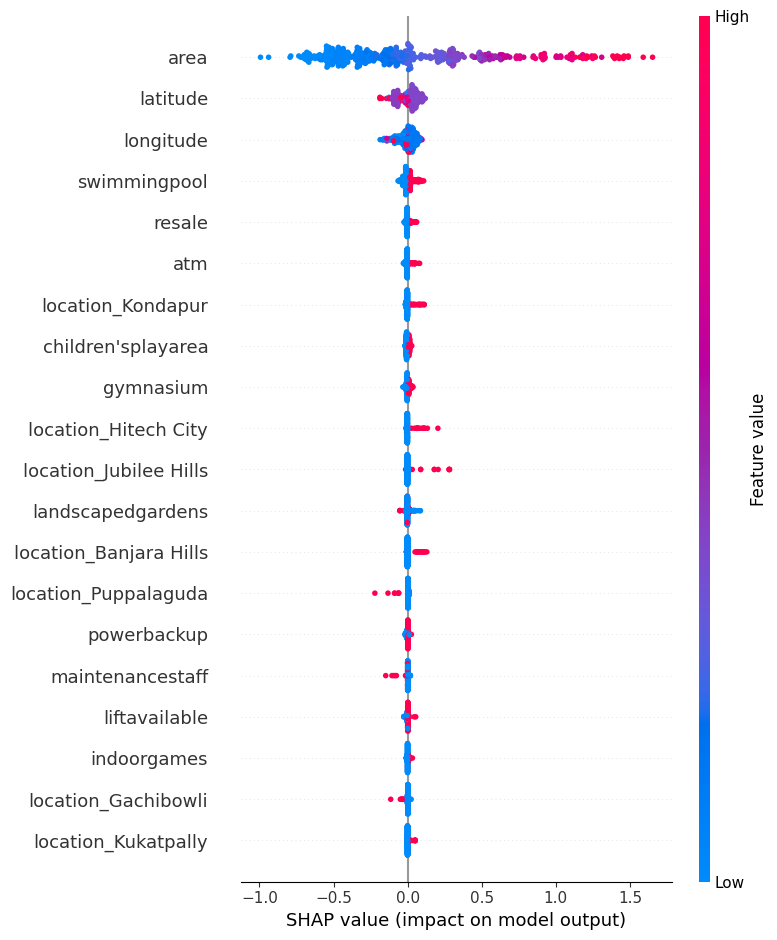

In [13]:
shap.summary_plot(
    shap_values,
    X_test
)

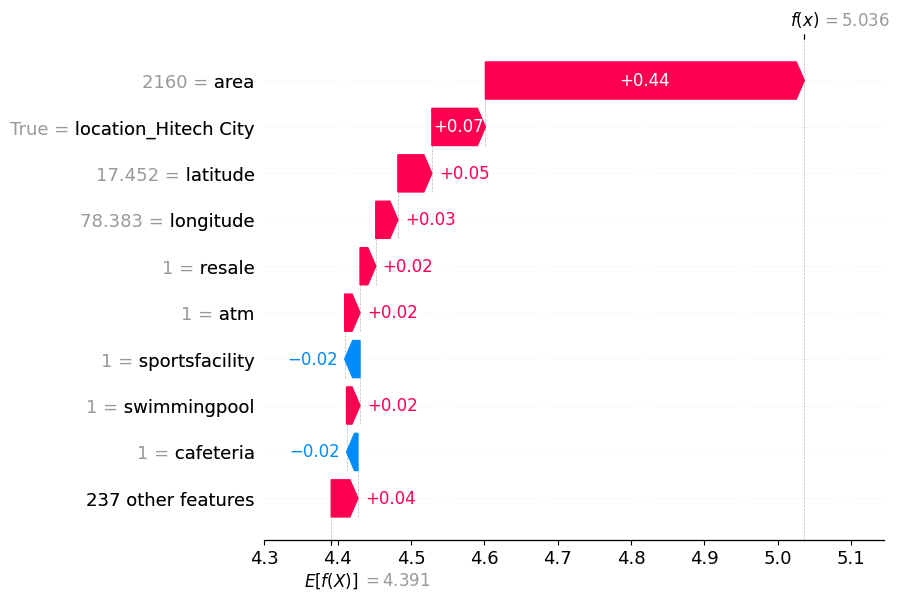

In [14]:
shap.plots.waterfall(shap_values[0],show=False)
plt.savefig(
    "../plots/waterfall_plot.png",
    bbox_inches='tight',
    
)
plt.show()

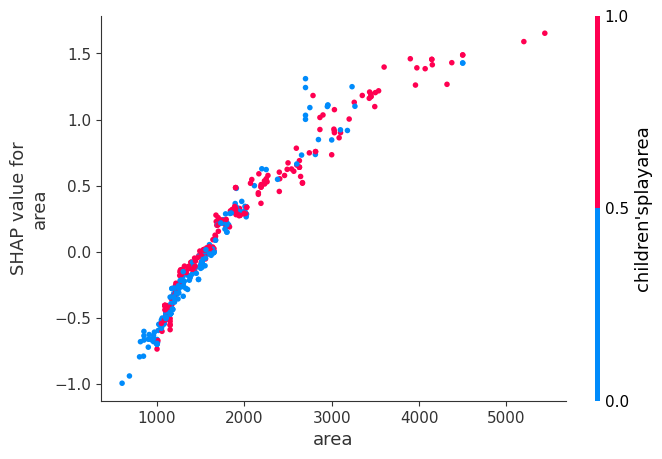

In [15]:
shap.dependence_plot(
    "area",
    shap_values.values,
    X_test,

    show=False
)
plt.savefig(
    "../plots/shap_dependence_plot.png",
    bbox_inches='tight'
)
plt.show()

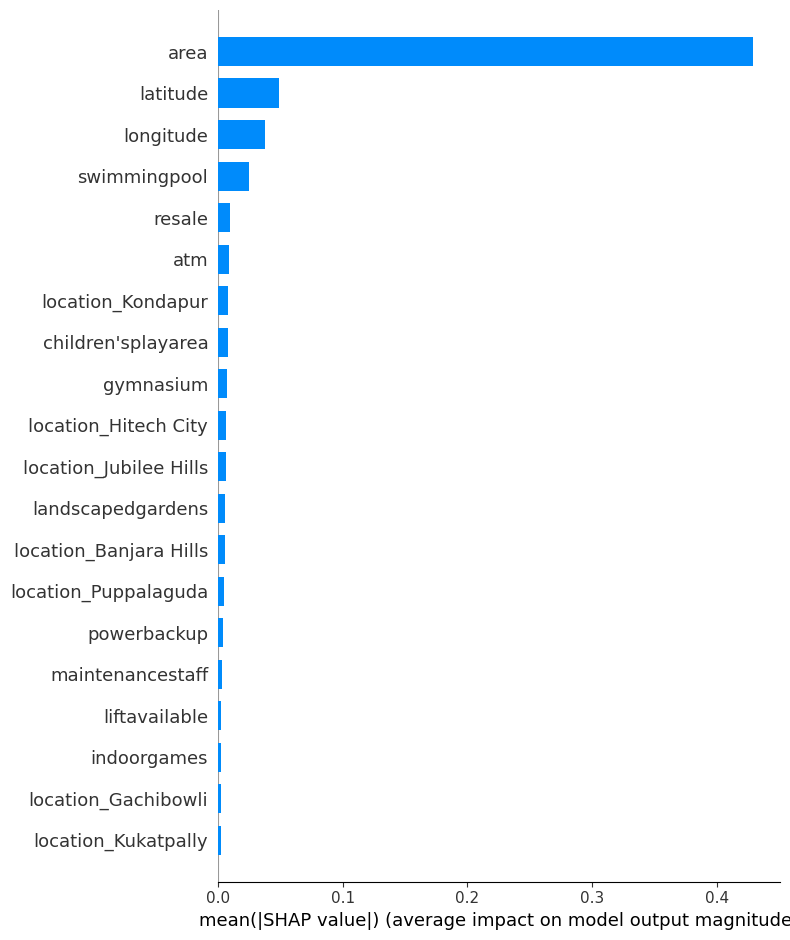

In [16]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    show=False
)
plt.savefig(
    '../plots/shap_summary.png',
    bbox_inches='tight'
)
plt.show()

In [17]:
import joblib

joblib.dump(model, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']

In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2276 entries, 0 to 2275
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                2276 non-null   float64
 1   area                 2276 non-null   int64  
 2   location             2276 non-null   str    
 3   no_of_bedrooms       2276 non-null   float64
 4   resale               2276 non-null   int64  
 5   maintenancestaff     2276 non-null   float64
 6   gymnasium            2276 non-null   float64
 7   swimmingpool         2276 non-null   float64
 8   landscapedgardens    2276 non-null   float64
 9   joggingtrack         2276 non-null   float64
 10  rainwaterharvesting  2276 non-null   float64
 11  indoorgames          2276 non-null   float64
 12  shoppingmall         2276 non-null   float64
 13  intercom             2276 non-null   float64
 14  sportsfacility       2276 non-null   float64
 15  atm                  2276 non-null   float64
 16 